In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

zip_path = '/content/drive/MyDrive/Pneumonia Project/pneumonia_data.zip'

if os.path.exists(zip_path):
    print(f"[+] Đã tìm thấy file tại: {zip_path}")
    print("[*] Đang tiến hành copy và giải nén...")

    os.system(f'cp "{zip_path}" /content/')
    os.system('unzip -q /content/pneumonia_data.zip -d /content/pneumonia_data')

    print("\n🎉 GIẢI NÉN HOÀN TẤT! Dữ liệu đã sẵn sàng.")
else:
    print(f"\n[!] LỖI: Không tìm thấy file tại {zip_path}")
    print("Vui lòng kiểm tra lại đường dẫn trên Google Drive của bạn.")

[+] Đã tìm thấy file tại: /content/drive/MyDrive/Pneumonia Project/pneumonia_data.zip
[*] Đang tiến hành copy và giải nén...

🎉 GIẢI NÉN HOÀN TẤT! Dữ liệu đã sẵn sàng.


In [ ]:
%%writefile dataset.py
"""
Dataset loader cho Pneumonia Classification.
- Tiền xử lý: CLAHE (cân bằng histogram thích ứng)
- Augmentation mạnh để chống overfitting và domain shift
- WeightedRandomSampler để cân bằng class trong batch
"""
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split

# Su dung CLAHE
def apply_clahe(pil_img):
    img = np.array(pil_img.convert('L'))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return Image.fromarray(img).convert('RGB')


class PneumoniaDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['Image Index']
        img_path = os.path.join(self.img_dir, img_name)
        label = self.dataframe.iloc[idx]['Label']
        image = Image.open(img_path)
        image = apply_clahe(image)
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)


def prepare_dataloaders(data_dir, batch_size=32):
    """Chuẩn bị train/val DataLoaders với class balancing."""
    csv_path = os.path.join(data_dir, 'balanced_labels.csv')
    img_dir = os.path.join(data_dir, 'images')
    df = pd.read_csv(csv_path)

    data_transforms = {
        'train': transforms.Compose([
            transforms.Resize(256),
            transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ColorJitter(brightness=0.2, contrast=0.3),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.1)),
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    }

    train_df, val_df = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df['Label']
    )
    train_dataset = PneumoniaDataset(train_df, img_dir, transform=data_transforms['train'])
    val_dataset = PneumoniaDataset(val_df, img_dir, transform=data_transforms['val'])

    # WeightedRandomSampler để cân bằng 1:1 trong mỗi batch
    labels = train_df['Label'].values
    class_count = np.array([len(np.where(labels == t)[0]) for t in np.unique(labels)])
    weight = 1. / class_count
    samples_weight = torch.from_numpy(np.array([weight[int(t)] for t in labels]))
    sampler = WeightedRandomSampler(samples_weight.double(), len(samples_weight))

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, sampler=sampler,
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )
    return train_loader, val_loader


Writing dataset.py


In [ ]:
%%writefile model.py
"""
Định nghĩa kiến trúc model.
- Backbone: ResNet18 pretrain ImageNet
- Selective fine-tuning: chỉ train Layer 3 + Layer 4
- Custom head: Dropout 0.3 + Linear → 1 logit (binary classification)
"""
import torch
import torch.nn as nn
from torchvision import models


def get_resnet18_model(device, freeze_mode='all'):
    """Khởi tạo model ResNet18 cho phân loại nhị phân.

    Args:
        device: torch.device (cuda hoặc cpu)
        freeze_mode: 'all' = đóng băng toàn bộ backbone (Stage 1)
                     'selective' = mở khóa layer3 + layer4 (Stage 2)
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_mode == 'all':
        for param in model.parameters():
            param.requires_grad = False
        print("[*] Freeze TOÀN BỘ backbone.")
    elif freeze_mode == 'selective':
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer3.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True
        print("[*] Fine-tune: Layer 3 + Layer 4.")

    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),          # fc.0
        nn.Linear(num_ftrs, 256), # fc.1 -> nhận vào 512, đầu ra 256
        nn.ReLU(),                # fc.2
        nn.Dropout(0.3),          # fc.3
        nn.Linear(256, 1)         # fc.4 -> nhận vào 256, đầu ra 1 logit
    )
    return model.to(device)


Writing model.py


In [ ]:
%%writefile train.py
"""
Training pipeline 3 giai đoạn:
- Stage 1: Freeze backbone, train classifier head (lr=1e-3)
- Stage 2: Fine-tune Layer 3+4 (lr=1e-5)
- Stage 3: Threshold tuning trên validation set
"""
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve
)
from dataset import prepare_dataloaders
from model import get_resnet18_model


class EarlyStopping:
    """Early stopping dựa trên validation loss."""
    def __init__(self, patience=5, path='best_model_v1.pth'):
        self.patience = patience
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.path = path

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)


def run_epoch(model, loader, criterion, optimizer, device, phase='train'):
    """Chạy 1 epoch (train hoặc validate) và trả về dict các metrics."""
    if phase == 'train':
        model.train()
        # Giữ BatchNorm ở eval khi backbone bị freeze
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                if not next(m.parameters()).requires_grad:
                    m.eval()
    else:
        model.eval()

    running_loss, total = 0.0, 0
    probs_list, labels_list = [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1)
        if phase == 'train':
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        total += labels.size(0)
        probs_list.extend(torch.sigmoid(outputs).detach().cpu().numpy())
        labels_list.extend(labels.detach().cpu().numpy())

    probs_arr = np.array(probs_list)
    labels_arr = np.array(labels_list)
    preds_arr = (probs_arr >= 0.5).astype(int)

    return {
        'loss': running_loss / total,
        'acc': (preds_arr == labels_arr).mean(),
        'auc': roc_auc_score(labels_arr, probs_arr),
        'precision': precision_score(labels_arr, preds_arr, zero_division=0),
        'recall': recall_score(labels_arr, preds_arr, zero_division=0),
        'f1': f1_score(labels_arr, preds_arr, zero_division=0),
        'cm': confusion_matrix(labels_arr, preds_arr) if phase == 'val' else None,
    }


def get_val_predictions(model, val_loader, device):
    """Chạy inference trên val set, trả về (probs, labels) full set."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            p = torch.sigmoid(model(x)).cpu().numpy().flatten()
            all_probs.extend(p)
            all_labels.extend(y.numpy().flatten())
    return np.array(all_probs), np.array(all_labels)


def tune_threshold(all_probs, all_labels, target='f1'):
    """Tìm threshold tối ưu trên val set.

    Args:
        target: 'f1' (cân bằng) hoặc 'medical' (Recall >= 0.90)
    """
    precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

    if target == 'f1':
        f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
        best_idx = f1s[:-1].argmax()
        return (float(thresholds[best_idx]), float(f1s[best_idx]),
                float(precisions[best_idx]), float(recalls[best_idx]))

    elif target == 'medical':
        mask = recalls[:-1] >= 0.90
        if mask.any():
            valid_p = precisions[:-1][mask]
            valid_t = thresholds[mask]
            valid_r = recalls[:-1][mask]
            best_idx = valid_p.argmax()
            return (float(valid_t[best_idx]), None,
                    float(valid_p[best_idx]), float(valid_r[best_idx]))
        return None


def train_model():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, val_loader = prepare_dataloaders('/content/pneumonia_data', 32)

    criterion = nn.BCEWithLogitsLoss()

    history = {k: [] for k in ['t_loss', 'v_loss', 't_acc', 'v_acc',
                               't_auc', 'v_auc', 'v_recall', 'v_f1']}
    best_cm = None

    # ===== STAGE 1: FREEZE BACKBONE =====
    print("\n[STAGE 1] Freeze Backbone with Regularization")
    model = get_resnet18_model(DEVICE, freeze_mode='all')
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    early_stopper = EarlyStopping(patience=5, path='best_model_v1.pth')

    for epoch in range(8):
        t = run_epoch(model, train_loader, criterion, optimizer, DEVICE, 'train')
        v = run_epoch(model, val_loader, criterion, None, DEVICE, 'val')
        scheduler.step(v['loss'])
        for k, val in zip(history.keys(),
                          [t['loss'], v['loss'], t['acc'], v['acc'],
                           t['auc'], v['auc'], v['recall'], v['f1']]):
            history[k].append(val)
        print(f"E{epoch+1}/8 | Val Acc: {v['acc']:.4f} | Recall: {v['recall']:.4f} | "
              f"F1: {v['f1']:.4f} | AUC: {v['auc']:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        early_stopper(v['loss'], model)
        if early_stopper.early_stop:
            print("[!] Early stopping at Stage 1")
            break

    # ===== STAGE 2: FINE-TUNE =====
    print("\n[STAGE 2] Fine-tuning with Regularization")
    model.load_state_dict(torch.load('best_model_v1.pth'))
    for param in model.parameters():
        param.requires_grad = True
    optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)
    early_stopper = EarlyStopping(patience=5, path='best_model_v1.pth')

    for epoch in range(12):
        t = run_epoch(model, train_loader, criterion, optimizer, DEVICE, 'train')
        v = run_epoch(model, val_loader, criterion, None, DEVICE, 'val')
        scheduler.step(v['loss'])
        for k, val in zip(history.keys(),
                          [t['loss'], v['loss'], t['acc'], v['acc'],
                           t['auc'], v['auc'], v['recall'], v['f1']]):
            history[k].append(val)
        print(f"E{len(history['t_loss'])}/20 | Val Acc: {v['acc']:.4f} | "
              f"Recall: {v['recall']:.4f} | F1: {v['f1']:.4f} | AUC: {v['auc']:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")
        if v['loss'] <= min(history['v_loss']):
            best_cm = v['cm']
        early_stopper(v['loss'], model)
        if early_stopper.early_stop:
            print("[!] Early stopping at Stage 2")
            break

    # ===== STAGE 3: TUNE THRESHOLD =====
    print("\n[STAGE 3] Tuning decision threshold")
    model.load_state_dict(torch.load('best_model_v1.pth'))
    all_probs, all_labels = get_val_predictions(model, val_loader, DEVICE)

    thr_f1, f1_score_val, prec_f1, rec_f1 = tune_threshold(all_probs, all_labels, target='f1')
    print(f"[F1-Optimal] Threshold: {thr_f1:.4f} | F1: {f1_score_val:.4f} | "
          f"P: {prec_f1:.4f} | R: {rec_f1:.4f}")

    medical_result = tune_threshold(all_probs, all_labels, target='medical')
    if medical_result:
        thr_med, _, prec_med, rec_med = medical_result
        print(f"[Medical] Threshold: {thr_med:.4f} | P: {prec_med:.4f} | "
              f"R: {rec_med:.4f} (≥90%)")
    else:
        thr_med = None
        print("[Medical] Không tìm được threshold cho Recall ≥ 90%")

    # Lưu checkpoint với cả 2 threshold
    torch.save({
        'state_dict': model.state_dict(),
        'threshold_f1': thr_f1,
        'threshold_medical': thr_med,
        'val_f1': f1_score_val,
        'val_precision_f1': prec_f1,
        'val_recall_f1': rec_f1,
    }, 'best_model_final.pth')
    print(f"[*] Saved best_model_final.pth")

    # ===== VẼ LEARNING CURVES =====
    plt.figure(figsize=(18, 4))
    for i, (m, t_k, v_k) in enumerate([
        ('Loss', 't_loss', 'v_loss'),
        ('Recall & F1', 'v_recall', 'v_f1'),
        ('AUC', 't_auc', 'v_auc'),
    ]):
        plt.subplot(1, 3, i + 1)
        if t_k in history:
            plt.plot(history[t_k], label='Train')
        plt.plot(history[v_k], label='Val')
        plt.title(m); plt.legend()
    plt.tight_layout()
    plt.savefig('learning_curves_full.png')
    plt.show()

    # ===== CONFUSION MATRICES =====
    fig, axes = plt.subplots(1, 2 if not thr_med else 3, figsize=(6 * (3 if thr_med else 2), 5))
    if best_cm is not None:
        sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'Threshold = 0.5')
        axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

    preds_f1 = (all_probs >= thr_f1).astype(int)
    cm_f1 = confusion_matrix(all_labels, preds_f1)
    sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title(f'F1-Optimal (Thr = {thr_f1:.3f})')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

    if thr_med:
        preds_med = (all_probs >= thr_med).astype(int)
        cm_med = confusion_matrix(all_labels, preds_med)
        sns.heatmap(cm_med, annot=True, fmt='d', cmap='Reds', ax=axes[2])
        axes[2].set_title(f'Medical (Thr = {thr_med:.3f})')
        axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig('confusion_matrices.png')
    plt.show()


if __name__ == '__main__':
    train_model()


Writing train.py


[*] Đang khởi tạo quy trình đánh giá với Ngưỡng quyết định cố định: 0.44
    - Quy mô tập Validation dùng để kiểm thử: 1145 ảnh

[*] Đang nạp mô hình ResNet18 trên thiết bị: cuda
[+] Nạp file trọng số .pth thành công!

[*] AI đang quét tập dữ liệu để thu thập xác suất dự đoán...

📊 KẾT QUẢ ĐÁNH GIÁ TỪ FILE EVALUATE (Cố định Threshold: 0.440)
  - Accuracy (Độ chính xác tổng):    74.24%
  - Precision (Độ chính xác dự đoán): 48.88%
  - Recall / Sensitivity (Độ nhạy):  68.88%
  - Specificity (Độ đặc hiệu):       76.02%
  - F1-Score (Chỉ số F1):            57.18%
  - AUC-ROC Value:                   0.7968
  - AUC-PR (AP Value):               0.5857
--------------------------------------------------

📝 CHI TIẾT CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.88      0.76      0.82       859
   Pneumonia       0.49      0.69      0.57       286

    accuracy                           0.74      1145
   macro avg       0.68      0.72      0.69

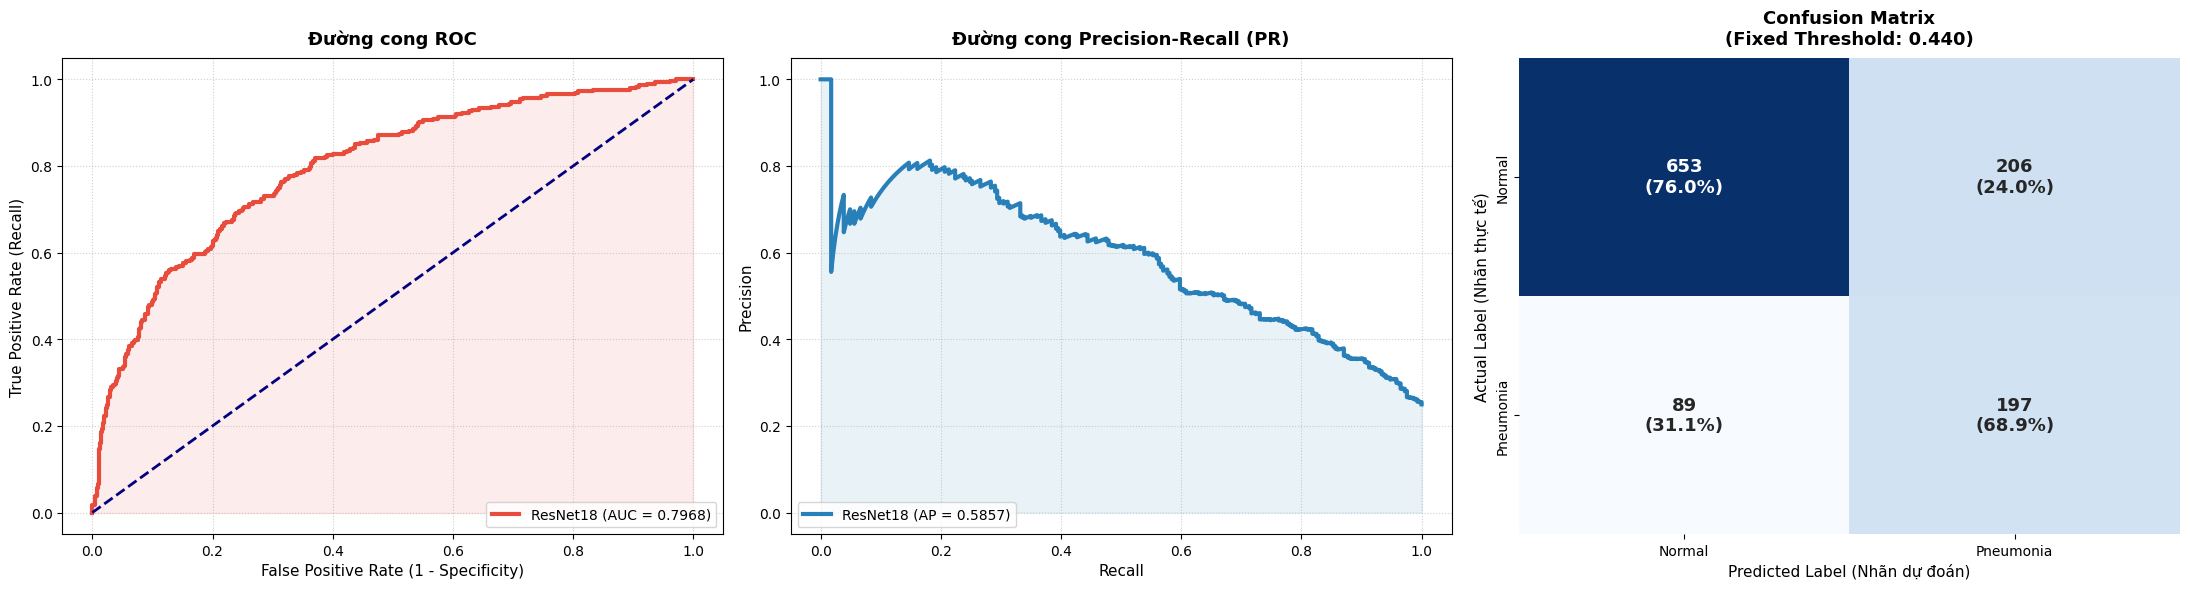

In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

fixed_threshold = 0.440

print(f"[*] Đang khởi tạo quy trình đánh giá với Ngưỡng quyết định cố định: {fixed_threshold}")
print(f"    - Quy mô tập Validation dùng để kiểm thử: {len(val_df)} ảnh")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[*] Đang nạp mô hình ResNet18 trên thiết bị: {device}")

# Khởi tạo mô hình ResNet18 gốc từ torchvision
import torchvision.models as models
model = models.resnet18(weights=None)

# Thay đổi cấu hình Head FC khớp 100% với file state_dict (2 tầng tuyến tính)
model.fc = torch.nn.Sequential(
    torch.nn.Dropout(0.3),
    torch.nn.Linear(512, 256),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(256, 1)
)

# Nạp trọng số từ file checkpoint đã lưu
checkpoint_path = '/content/best_model_final.pth'
try:
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt.get('state_dict', ckpt))
    print("[+] Nạp file trọng số .pth thành công!")
except FileNotFoundError:
    print(f"[!] LỖI: Không tìm thấy file trọng số tại {checkpoint_path}. Hãy kiểm tra lại đường dẫn.")

model.to(device)
model.eval()

# Hàm trích xuất Xác suất dự đoán (Probability) và Nhãn thực tế (Labels)
def get_probabilities_and_labels(dataframe):
    dataset = DS(dataframe, img_dir, tf)  # Gọi class Dataset được định nghĩa ở Cell 2
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).squeeze(-1)
            probs = torch.sigmoid(outputs)  # Chuyển đổi logits về dải xác suất [0, 1]

            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(labels.numpy().ravel())

    return np.array(all_probs), np.array(all_labels)

print("\n[*] AI đang quét tập dữ liệu để thu thập xác suất dự đoán...")
probs_test, labels_test = get_probabilities_and_labels(val_df)

# Áp dụng ngưỡng cố định 0.440 để đưa ra nhãn dự đoán
preds_test = (probs_test >= fixed_threshold).astype(int)

# Tính toán các chỉ số chất lượng mô hình cốt lõi
acc = accuracy_score(labels_test, preds_test)
precision = precision_score(labels_test, preds_test)
recall = recall_score(labels_test, preds_test)
f1 = f1_score(labels_test, preds_test)
auc_roc = roc_auc_score(labels_test, probs_test)
auc_pr = average_precision_score(labels_test, probs_test)

# Tính Specificity (Độ đặc hiệu) từ ma trận nhầm lẫn
tn, fp, fn, tp = confusion_matrix(labels_test, preds_test).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "="*50)
print(f"📊 KẾT QUẢ ĐÁNH GIÁ TỪ FILE EVALUATE (Cố định Threshold: {fixed_threshold:.3f})")
print("="*50)
print(f"  - Accuracy (Độ chính xác tổng):    {acc*100:.2f}%")
print(f"  - Precision (Độ chính xác dự đoán): {precision*100:.2f}%")
print(f"  - Recall / Sensitivity (Độ nhạy):  {recall*100:.2f}%")
print(f"  - Specificity (Độ đặc hiệu):       {specificity*100:.2f}%")
print(f"  - F1-Score (Chỉ số F1):            {f1*100:.2f}%")
print(f"  - AUC-ROC Value:                   {auc_roc:.4f}")
print(f"  - AUC-PR (AP Value):               {auc_pr:.4f}")
print("-"*50)

print("\n📝 CHI TIẾT CLASSIFICATION REPORT:")
print(classification_report(labels_test, preds_test, target_names=['Normal', 'Pneumonia']))
print("[*] Đang khởi tạo chuỗi đồ thị phân tích chất lượng mô hình...")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Vẽ đường cong AUC-ROC
fpr, tpr, _ = roc_curve(labels_test, probs_test)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=3, label=f'ResNet18 (AUC = {auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_title('Đường cong ROC', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=11)
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 2. Vẽ đường cong AUC-PR
p_curve, r_curve, _ = precision_recall_curve(labels_test, probs_test)
axes[1].plot(r_curve, p_curve, color='#2980b9', lw=3, label=f'ResNet18 (AP = {auc_pr:.4f})')
axes[1].fill_between(r_curve, p_curve, alpha=0.1, color='#2980b9')
axes[1].set_title('Đường cong Precision-Recall (PR)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].legend(loc="lower left", fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

# 3. Vẽ biểu đồ Ma trận nhầm lẫn (Confusion Matrix) kèm Tỷ lệ %
cm = confusion_matrix(labels_test, preds_test)
annot_labels = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percentage = count / cm[i].sum() * 100
        annot_labels[i, j] = f"{count}\n({percentage:.1f}%)"

sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'],
            cbar=False, ax=axes[2], annot_kws={"size": 13, "weight": "bold"})
axes[2].set_title(f'Confusion Matrix\n(Fixed Threshold: {fixed_threshold:.3f})', fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Predicted Label (Nhãn dự đoán)', fontsize=11)
axes[2].set_ylabel('Actual Label (Nhãn thực tế)', fontsize=11)

plt.tight_layout()
output_image_path = 'final_test_evaluation_metrics.png'
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
print(f"🎉 THÀNH CÔNG! Đã xuất chuỗi đồ thị chất lượng cao tại file: {output_image_path}")
plt.show()

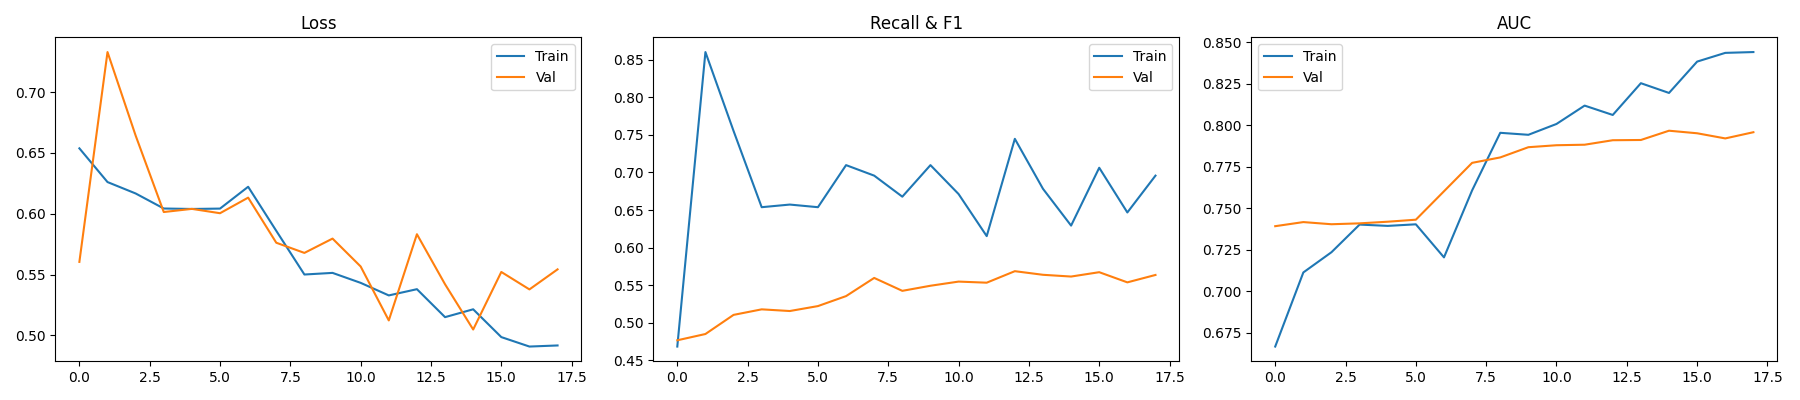

In [ ]:
from IPython.display import Image, display
import os

# Hiển thị biểu đồ đã được lưu từ script train.py
if os.path.exists('learning_curves_full.png'):
    display(Image('learning_curves_full.png'))
else:
    print("Chưa tìm thấy file biểu đồ. Vui lòng đảm bảo cell huấn luyện đã chạy xong.")

In [ ]:
%%writefile predict.py
"""
Dự đoán ảnh X-quang đơn lẻ (dùng cho demo).
- Tiền xử lý CLAHE
- Test-Time Augmentation (TTA): trung bình prediction của ảnh gốc + ảnh lật ngang
- Sử dụng threshold tối ưu đã lưu trong checkpoint
"""
import sys
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from model import get_resnet18_model
from dataset import apply_clahe

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def predict(image_path, ckpt_path='best_model_final.pth', mode='f1'):
    """Dự đoán 1 ảnh.

    Args:
        image_path: đường dẫn ảnh X-quang
        ckpt_path: checkpoint đã train
        mode: 'f1' (cân bằng) hoặc 'medical' (Recall cao)
    """
    # Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    if mode == 'medical' and ckpt.get('threshold_medical'):
        threshold = ckpt['threshold_medical']
    else:
        threshold = ckpt.get('threshold_f1', 0.455)

    # Load model
    model = get_resnet18_model(DEVICE, freeze_mode='selective')
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    # Tiền xử lý
    img = Image.open(image_path).convert('RGB')
    img_clahe = apply_clahe(img)

    # Test-Time Augmentation
    probs = []
    with torch.no_grad():
        for im in [img_clahe, img_clahe.transpose(Image.FLIP_LEFT_RIGHT)]:
            x = transform(im).unsqueeze(0).to(DEVICE)
            probs.append(torch.sigmoid(model(x)).item())

    prob = float(np.mean(probs))
    label = "PNEUMONIA" if prob >= threshold else "NORMAL"
    confidence = prob if prob >= threshold else (1 - prob)

    print(f"\n{'='*50}")
    print(f"📷 File: {image_path}")
    print(f"{'='*50}")
    print(f"  Probability (Pneumonia): {prob:.4f} ({prob*100:.2f}%)")
    print(f"  Threshold ({mode}):      {threshold}")
    print(f"  Confidence:              {confidence*100:.2f}%")
    print(f"  → PREDICTION: {label}")
    print(f"{'='*50}\n")

    return {'probability': prob, 'label': label,
            'confidence': confidence, 'threshold': threshold}


if __name__ == '__main__':
    if len(sys.argv) < 2:
        print("Usage: python predict.py <image_path> [mode]")
        print("  mode: 'f1' (default) or 'medical'")
        sys.exit(1)
    image_path = sys.argv[1]
    mode = sys.argv[2] if len(sys.argv) > 2 else 'f1'
    predict(image_path, mode=mode)


Writing predict.py


In [ ]:
!cp /content/best_model_v1.pth /content/drive/MyDrive/Pneumonia\ Project/best_model_BACKUP_resnet18.pth
!cp /content/best_model_final.pth /content/drive/MyDrive/Pneumonia\ Project/best_model_final_BACKUP.pth

In [ ]:
import os, cv2, numpy as np, pandas as pd
from PIL import Image
import torch, torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, precision_recall_curve)

def apply_clahe(p):
    img = np.array(p.convert('L'))
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(img)
    return Image.fromarray(img).convert('RGB')

class DS(Dataset):
    def __init__(self, df, d, t): self.df, self.d, self.t = df, d, t
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        im = apply_clahe(Image.open(os.path.join(self.d, r['Image Index'])))
        return self.t(im), torch.tensor(r['Label'], dtype=torch.float32)

data_dir = '/content/pneumonia_data'
df = pd.read_csv(os.path.join(data_dir, 'balanced_labels.csv'))
img_dir = os.path.join(data_dir, 'images')

# Tách giống lúc train, RỒI chia đôi val -> threshold-set + test-set
_, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])
thr_df, test_df = train_test_split(val_df, test_size=0.5, random_state=42, stratify=val_df['Label'])

tf = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

device = torch.device('cpu')
model = models.resnet18(weights=None)

# >>> CHỌN ĐÚNG HEAD theo Bước 1 <<<
HEAD_DEF = '512_256_1'    # đổi thành '512_256_1' nếu Bước 1 cho ra head sâu
if HEAD_DEF == '512_1':
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, 1))
else:
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512,256), nn.ReLU(),
                             nn.Dropout(0.3), nn.Linear(256,1))

ckpt = torch.load('/content/best_model_final.pth', map_location=device)
model.load_state_dict(ckpt.get('state_dict', ckpt))
model.to(device).eval()

def get_probs(d):
    loader = DataLoader(DS(d, img_dir, tf), batch_size=32, shuffle=False)
    P, L = [], []
    with torch.no_grad():
        for x, y in loader:
            P.extend(torch.sigmoid(model(x)).squeeze(-1).numpy().ravel())
            L.extend(y.numpy().ravel())
    return np.array(P), np.array(L)

# 1) Tune threshold trên thr_df
p_thr, l_thr = get_probs(thr_df)
prec, rec, thr = precision_recall_curve(l_thr, p_thr)
f1s = 2*prec*rec/(prec+rec+1e-8)
best_t = float(thr[f1s[:-1].argmax()])
print(f"Threshold tối ưu (chọn trên thr-set): {best_t:.3f}")

# 2) Báo cáo trên test_df (chưa từng dùng để chọn threshold)
p_te, l_te = get_probs(test_df)
pred = (p_te >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(l_te, pred).ravel()
print("\n=== KẾT QUẢ TRÊN TEST SET (trung thực) ===")
print(f"Accuracy   : {accuracy_score(l_te,pred)*100:.2f}%")
print(f"Precision  : {precision_score(l_te,pred)*100:.2f}%")
print(f"Recall     : {recall_score(l_te,pred)*100:.2f}%")
print(f"Specificity: {tn/(tn+fp)*100:.2f}%")
print(f"F1-Score   : {f1_score(l_te,pred)*100:.2f}%")


Threshold tối ưu (chọn trên thr-set): 0.440

=== KẾT QUẢ TRÊN TEST SET (trung thực) ===
Accuracy   : 72.77%
Precision  : 47.00%
Recall     : 71.33%
Specificity: 73.26%
F1-Score   : 56.67%
